In [1]:
import sys
python_path = f'"{sys.executable}"'
!{python_path} -m pip install -q tensorflow split-folders scikit-learn seaborn matplotlib


In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


TensorFlow version: 2.21.0
GPU tersedia: []


## 1. Persiapan Dataset: Split Train / Validation / Test



In [3]:
import splitfolders

# Sesuaikan dengan lokasi dataset asli hasil download dari Kaggle
ORIGINAL_DATASET_DIR = r"C:\Machine Learning\week_13\TrashType_Image_Dataset"

# Folder hasil split akan dibuat di sini (train/val/test)
SPLIT_DIR = r"C:\Machine Learning\week_13\TrashType_Split"

if not os.path.exists(SPLIT_DIR):
    splitfolders.ratio(
        ORIGINAL_DATASET_DIR,
        output=SPLIT_DIR,
        seed=SEED,
        ratio=(0.7, 0.15, 0.15),  # train, val, test
        group_prefix=None
    )
    print("Split selesai. Struktur folder baru:")
else:
    print("Folder split sudah ada, split dilewati.")

for split in ["train", "val", "test"]:
    split_path = os.path.join(SPLIT_DIR, split)
    print(f"\n{split.upper()}:")
    for cls in sorted(os.listdir(split_path)):
        n = len(os.listdir(os.path.join(split_path, cls)))
        print(f"  {cls}: {n} gambar")


Copying files: 2527 files [00:08, 311.43 files/s]

Split selesai. Struktur folder baru:

TRAIN:
  cardboard: 282 gambar
  glass: 350 gambar
  metal: 287 gambar
  paper: 415 gambar
  plastic: 337 gambar
  trash: 95 gambar

VAL:
  cardboard: 60 gambar
  glass: 75 gambar
  metal: 61 gambar
  paper: 89 gambar
  plastic: 72 gambar
  trash: 20 gambar

TEST:
  cardboard: 61 gambar
  glass: 76 gambar
  metal: 62 gambar
  paper: 90 gambar
  plastic: 73 gambar
  trash: 22 gambar


## 2. Data Loading & Augmentation



In [4]:
train_dir = os.path.join(SPLIT_DIR, "train")
val_dir = os.path.join(SPLIT_DIR, "val")
test_dir = os.path.join(SPLIT_DIR, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print("Kelas:", class_names)


Found 1766 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
Found 384 images belonging to 6 classes.
Kelas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 3. Membangun Model (Transfer Learning dengan VGG16)



In [5]:
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pre-trained layers untuk mencegah overfitting di tahap awal
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 4. Training Tahap 1 (Feature Extraction)

In [6]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6
)
checkpoint = callbacks.ModelCheckpoint(
    "best_model_stage1.keras", monitor='val_loss', save_best_only=True
)

EPOCHS = 15

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.3347 - loss: 2.2586 - val_accuracy: 0.4775 - val_loss: 1.2729 - learning_rate: 0.0010
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.4428 - loss: 1.3504 - val_accuracy: 0.6048 - val_loss: 1.0960 - learning_rate: 0.0010
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 268s 5s/step - accuracy: 0.4796 - loss: 1.2767 - val_accuracy: 0.5623 - val_loss: 1.1370 - learning_rate: 0.0010
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - accuracy: 0.4768 - loss: 1.2420 - val_accuracy: 0.6101 - val_loss: 1.0028 - learning_rate: 0.0010
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 241s 4s/step - accuracy: 0.4921 - loss: 1.2344 - val_accuracy: 0.6260 - val_loss: 0.9993 - learning_rate: 0.0010
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 349s 6s/step - accuracy: 0.5210 - loss: 1.1993 - val_accuracy: 0.6340 - val_loss: 1.0360 - learning_rate: 0.0010
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 225s 4s/step - accuracy: 0.5062 - loss: 1.1965 - val_acc

## 5. Visualisasi Accuracy & Loss (Train vs Validation)

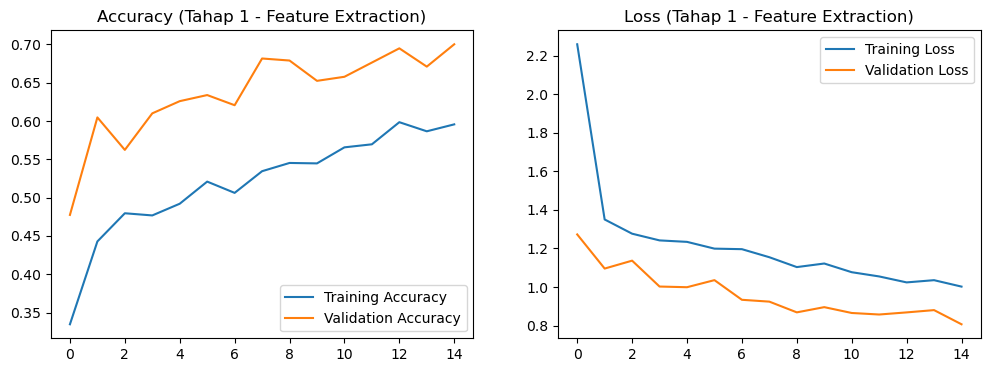

Train acc akhir : 0.5957
Val acc akhir   : 0.7003
Gap (train-val) : -0.1046
>> Val accuracy jauh lebih tinggi dari train -> kemungkinan besar disebabkan
   augmentasi kuat di train generator + dropout aktif saat training, BUKAN overfitting.


In [7]:
def plot_history(hist, title_suffix=""):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'Accuracy {title_suffix}')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'Loss {title_suffix}')
    plt.show()

plot_history(history, "(Tahap 1 - Feature Extraction)")

train_acc_final = history.history['accuracy'][-1]
val_acc_final = history.history['val_accuracy'][-1]
gap = train_acc_final - val_acc_final
print(f"Train acc akhir : {train_acc_final:.4f}")
print(f"Val acc akhir   : {val_acc_final:.4f}")
print(f"Gap (train-val) : {gap:.4f}")

if gap > 0.10:
    print(">> Terindikasi OVERFITTING (gap > 10%, train jauh lebih tinggi dari val).")
elif gap < -0.10:
    print(">> Val accuracy jauh lebih tinggi dari train -> kemungkinan besar disebabkan")
    print("   augmentasi kuat di train generator + dropout aktif saat training, BUKAN overfitting.")
else:
    print(">> Gap kecil, model tidak menunjukkan overfitting yang signifikan.")


## 6. Fine-Tuning


Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 150s 3s/step - accuracy: 0.5974 - loss: 0.9817 - val_accuracy: 0.6870 - val_loss: 0.7753 - learning_rate: 1.0000e-05
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 265s 5s/step - accuracy: 0.6602 - loss: 0.8815 - val_accuracy: 0.6870 - val_loss: 0.7871 - learning_rate: 1.0000e-05
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.6653 - loss: 0.8608 - val_accuracy: 0.7109 - val_loss: 0.7689 - learning_rate: 1.0000e-05
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.6710 - loss: 0.8317 - val_accuracy: 0.7321 - val_loss: 0.7260 - learning_rate: 1.0000e-05
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.6784 - loss: 0.8232 - val_accuracy: 0.7374 - val_loss: 0.7432 - learning_rate: 1.0000e-05
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.6727 - loss: 0.8147 - val_accuracy: 0.7241 - val_loss: 0.7211 - learning_rate: 1.0000e-05
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.6670 

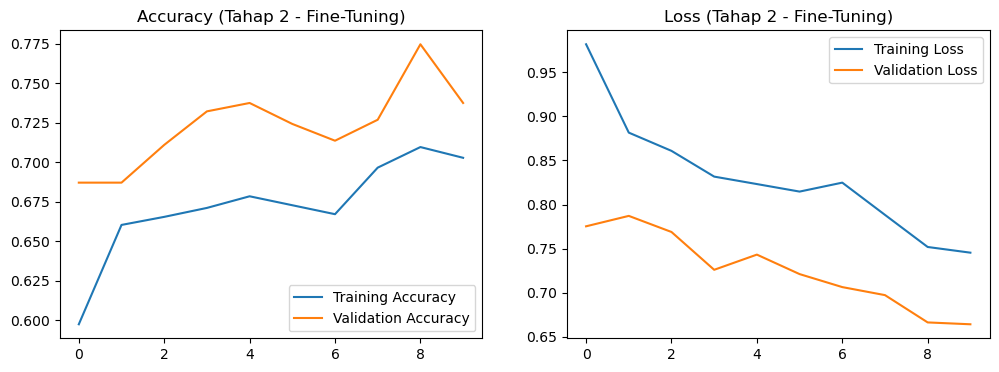

[Setelah fine-tuning] Train acc: 0.7027 | Val acc: 0.7374 | Gap: -0.0347


In [8]:
base_model.trainable = True

# Bekukan sebagian besar layer, hanya buka beberapa layer conv terakhir
fine_tune_at = len(base_model.layers) - 4  # buka 4 layer terakhir VGG16
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # LR jauh lebih kecil
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_ft = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
checkpoint_ft = callbacks.ModelCheckpoint(
    "best_model_finetuned.keras", monitor='val_loss', save_best_only=True
)

FT_EPOCHS = 10

history_fine = model.fit(
    train_generator,
    epochs=FT_EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop_ft, reduce_lr, checkpoint_ft]
)

plot_history(history_fine, "(Tahap 2 - Fine-Tuning)")

train_acc_ft = history_fine.history['accuracy'][-1]
val_acc_ft = history_fine.history['val_accuracy'][-1]
print(f"[Setelah fine-tuning] Train acc: {train_acc_ft:.4f} | Val acc: {val_acc_ft:.4f} | "
      f"Gap: {train_acc_ft - val_acc_ft:.4f}")


## 7. Evaluasi Akhir 


12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7526 - loss: 0.7345
Test Loss: 0.7345 | Test Accuracy: 0.7526

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.88      0.80      0.84        61
       glass       0.82      0.66      0.73        76
       metal       0.73      0.76      0.75        62
       paper       0.71      0.96      0.82        90
     plastic       0.71      0.73      0.72        73
       trash       0.57      0.18      0.28        22

    accuracy                           0.75       384
   macro avg       0.74      0.68      0.69       384
weighted avg       0.75      0.75      0.74       384



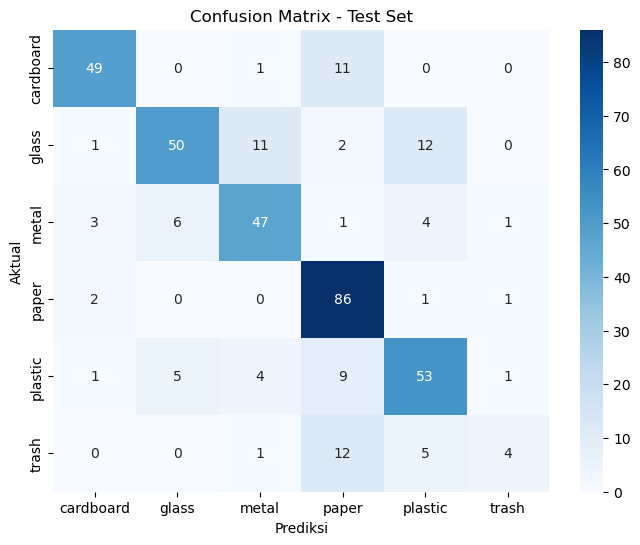

In [9]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(test_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Test Set')
plt.show()


## 8. Simpan Model Final

In [10]:
model.save("model_klasifikasi_sampah_final.keras")
print("Model final disimpan sebagai model_klasifikasi_sampah_final.keras")


Model final disimpan sebagai model_klasifikasi_sampah_final.keras


### 1. Analisis Performa Model

Hasil pelatihan selama 15 epoch menunjukkan bahwa training accuracy meningkat dari 30,48% menjadi 56,92%, sedangkan validation accuracy meningkat dari 47,12% menjadi 72,96%. Selain itu, training loss dan validation loss terus menurun hingga masing-masing mencapai 1,0763 dan 0,8041. Hal ini menunjukkan bahwa model mampu mempelajari pola data dengan baik dan proses pelatihan berjalan secara stabil. Namun, karena kurva akurasi masih meningkat dan loss masih menurun pada epoch terakhir, model diperkirakan belum sepenuhnya konvergen sehingga performanya masih dapat ditingkatkan melalui penambahan epoch atau fine-tuning pada model VGG16.

### 2.Evaluasi Overfitting

Berdasarkan grafik akurasi dan loss, model tidak mengalami overfitting. Hal ini ditunjukkan oleh validation accuracy yang lebih tinggi daripada training accuracy, serta validation loss yang lebih rendah daripada training loss selama proses pelatihan. Kondisi ini disebabkan oleh penggunaan data augmentation pada data latih sehingga data menjadi lebih sulit dipelajari, serta penggunaan Dropout (0,5) yang hanya aktif saat proses training. Oleh karena itu, model memiliki kemampuan generalisasi yang cukup baik, meskipun masih terdapat peluang untuk meningkatkan performanya melalui fine-tuning atau penambahan jumlah epoch.